# ViT分類器 訓練結果の可視化と分析

このノートブックでは、ViT (Vision Transformer) 分類器の訓練結果を可視化します。

## 対象データセット
- **ChestX-ray**: 胸部X線画像（NORMAL / PNEUMONIA）
- **DermMel**: 皮膚画像（Melanoma / NotMelanoma）
- **PCAm**: 病理画像（normal / tumor）

## 1. ライブラリのインポート

In [9]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

# 日本語フォント設定
plt.rcParams['font.family'] = ['DejaVu Sans', 'Hiragino Sans', 'Yu Gothic', 'Meirio', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# グラフスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("ライブラリのインポート完了")

ライブラリのインポート完了


## 2. チェックポイントディレクトリの探索

In [10]:
# チェックポイントディレクトリのベースパス
BASE_DIR = Path("/mnt/data1/gotou/projects/vit/classifiers/checkpoints")

# データセット情報を格納する辞書
datasets_info = {}

# 各データセットディレクトリを探索
for dataset_dir in BASE_DIR.iterdir():
    if dataset_dir.is_dir():
        dataset_name = dataset_dir.name
        
        # タイムスタンプディレクトリを探索（最新のものを使用）
        timestamp_dirs = sorted([d for d in dataset_dir.iterdir() if d.is_dir()])
        
        if timestamp_dirs:
            latest_dir = timestamp_dirs[-1]
            
            # 必要なファイルのパスを確認
            config_path = latest_dir / "config.json"
            history_path = latest_dir / "training_history.json"
            
            if config_path.exists() and history_path.exists():
                datasets_info[dataset_name] = {
                    'dir': latest_dir,
                    'config_path': config_path,
                    'history_path': history_path
                }
                print(f"✓ {dataset_name}: {latest_dir}")
            else:
                print(f"✗ {dataset_name}: 必要なファイルが見つかりません")

print(f"\n合計 {len(datasets_info)} データセットが見つかりました")

✓ chestxray: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/chestxray/20260117_190122
✓ pcam: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/pcam/20260117_210505
✓ dermmel: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/dermmel/20260118_175806

合計 3 データセットが見つかりました


## 3. 訓練ログデータの読み込み

In [11]:
# 訓練データを格納する辞書
training_data = {}

for dataset_name, info in datasets_info.items():
    # 設定ファイルの読み込み
    with open(info['config_path'], 'r') as f:
        config = json.load(f)
    
    # 訓練履歴の読み込み
    with open(info['history_path'], 'r') as f:
        history = json.load(f)
    
    # データを整理
    epochs = list(range(1, len(history['train_loss']) + 1))
    
    training_data[dataset_name] = {
        'config': config,
        'history': history,
        'epochs': epochs,
        'df': pd.DataFrame({
            'epoch': epochs,
            'train_loss': history['train_loss'],
            'train_acc': history['train_acc'],
            'val_loss': history['val_loss'],
            'val_acc': history['val_acc']
        })
    }
    
    print(f"\n=== {dataset_name.upper()} ===")
    print(f"  モデル: {config['model']}")
    print(f"  エポック数: {config['epochs']}")
    print(f"  バッチサイズ: {config['batch_size']}")
    print(f"  学習率: {config['lr']}")
    print(f"  クラス: {config['class_names']}")
    print(f"  ベスト検証精度: {config['best_val_acc']:.4f}")
    print(f"  テスト精度: {config['test_acc']:.4f}")


=== CHESTXRAY ===
  モデル: vit_b_16
  エポック数: 30
  バッチサイズ: 32
  学習率: 0.0001
  クラス: ['NORMAL', 'PNEUMONIA']
  ベスト検証精度: 0.9713
  テスト精度: 0.9231

=== PCAM ===
  モデル: vit_b_16
  エポック数: 30
  バッチサイズ: 32
  学習率: 0.0001
  クラス: ['normal', 'tumor']
  ベスト検証精度: 0.9769
  テスト精度: 0.9775

=== DERMMEL ===
  モデル: vit_b_16
  エポック数: 30
  バッチサイズ: 32
  学習率: 0.0001
  クラス: ['Melanoma', 'NotMelanoma']
  ベスト検証精度: 0.9654
  テスト精度: 0.9565


## 4. データセットごとのLoss曲線の可視化

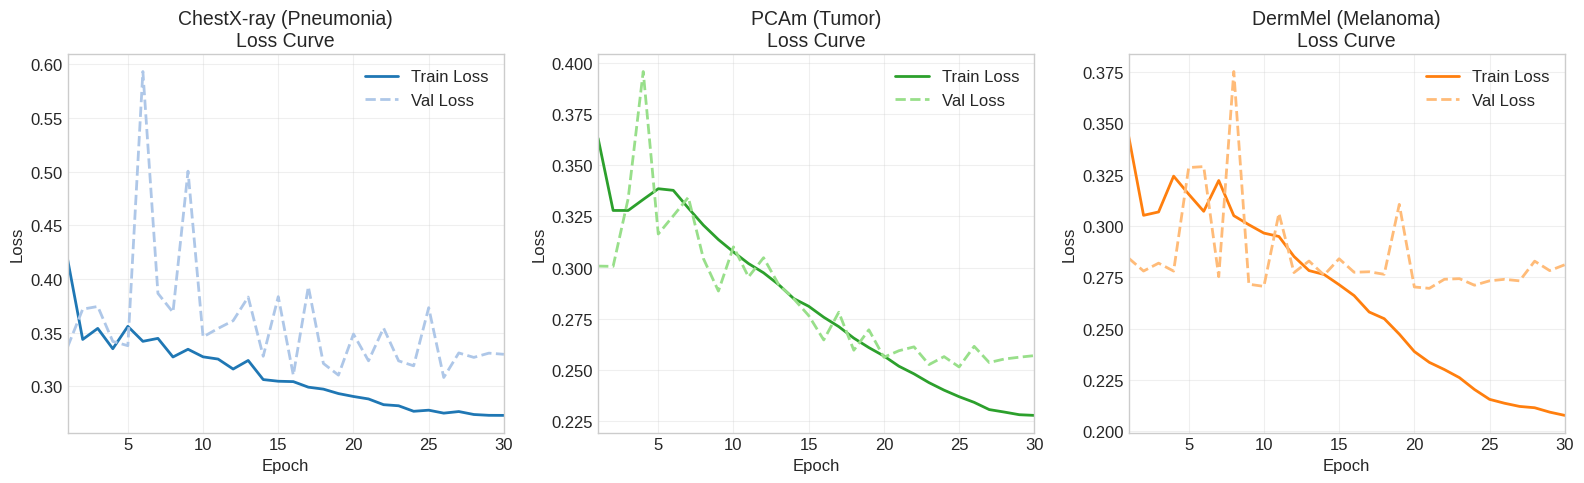


図を保存しました: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/loss_curves.png


In [12]:
# データセット名の表示名マッピング
dataset_display_names = {
    'chestxray': 'ChestX-ray (Pneumonia)',
    'dermmel': 'DermMel (Melanoma)',
    'pcam': 'PCAm (Tumor)'
}

# カラーパレット
colors = {
    'chestxray': {'train': '#1f77b4', 'val': '#aec7e8'},
    'dermmel': {'train': '#ff7f0e', 'val': '#ffbb78'},
    'pcam': {'train': '#2ca02c', 'val': '#98df8a'}
}

# 各データセットのLoss曲線をプロット
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (dataset_name, data) in enumerate(training_data.items()):
    ax = axes[idx]
    epochs = data['epochs']
    
    # 訓練Loss
    ax.plot(epochs, data['history']['train_loss'], 
            label='Train Loss', linewidth=2, color=colors[dataset_name]['train'])
    
    # 検証Loss
    ax.plot(epochs, data['history']['val_loss'], 
            label='Val Loss', linewidth=2, color=colors[dataset_name]['val'], linestyle='--')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'{dataset_display_names.get(dataset_name, dataset_name)}\nLoss Curve', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs))

plt.tight_layout()
plt.savefig(BASE_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n図を保存しました: {BASE_DIR / 'loss_curves.png'}")

## 5. データセットごとの精度曲線の可視化

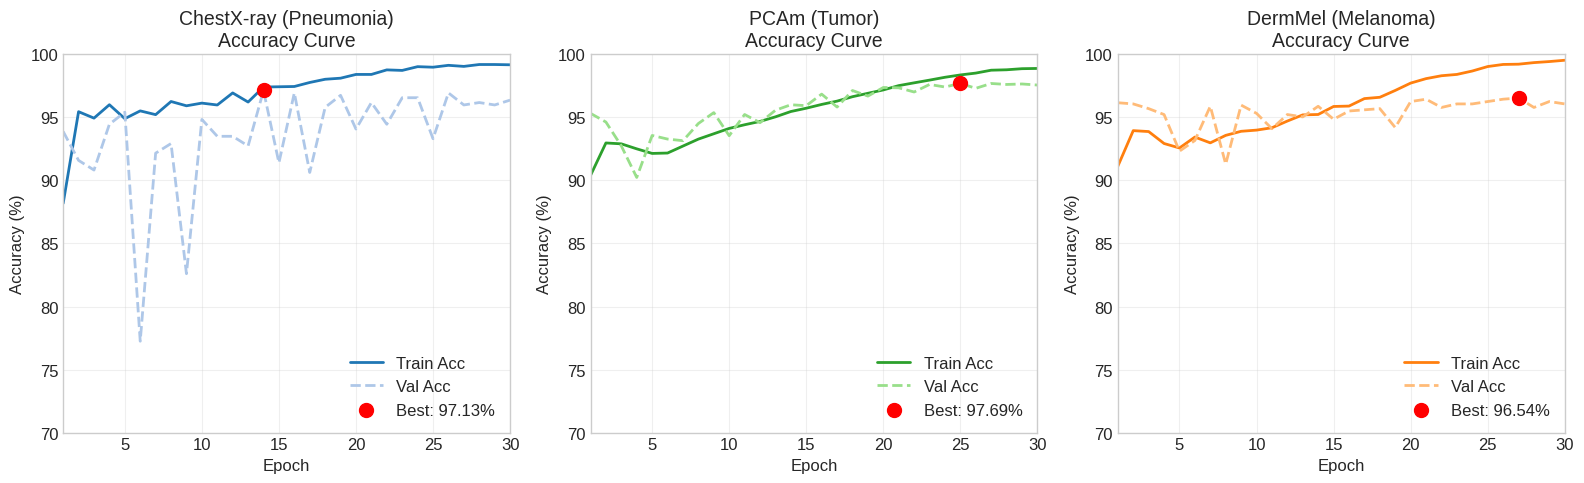


図を保存しました: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/accuracy_curves.png


In [13]:
# 各データセットの精度曲線をプロット
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (dataset_name, data) in enumerate(training_data.items()):
    ax = axes[idx]
    epochs = data['epochs']
    
    # 訓練精度
    ax.plot(epochs, [acc * 100 for acc in data['history']['train_acc']], 
            label='Train Acc', linewidth=2, color=colors[dataset_name]['train'])
    
    # 検証精度
    ax.plot(epochs, [acc * 100 for acc in data['history']['val_acc']], 
            label='Val Acc', linewidth=2, color=colors[dataset_name]['val'], linestyle='--')
    
    # ベスト検証精度の位置をマーク
    best_epoch = np.argmax(data['history']['val_acc']) + 1
    best_acc = max(data['history']['val_acc']) * 100
    ax.scatter([best_epoch], [best_acc], color='red', s=100, zorder=5, 
               label=f'Best: {best_acc:.2f}%')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{dataset_display_names.get(dataset_name, dataset_name)}\nAccuracy Curve', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs))
    ax.set_ylim(70, 100)

plt.tight_layout()
plt.savefig(BASE_DIR / 'accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n図を保存しました: {BASE_DIR / 'accuracy_curves.png'}")

## 6. 全データセットの比較グラフ作成

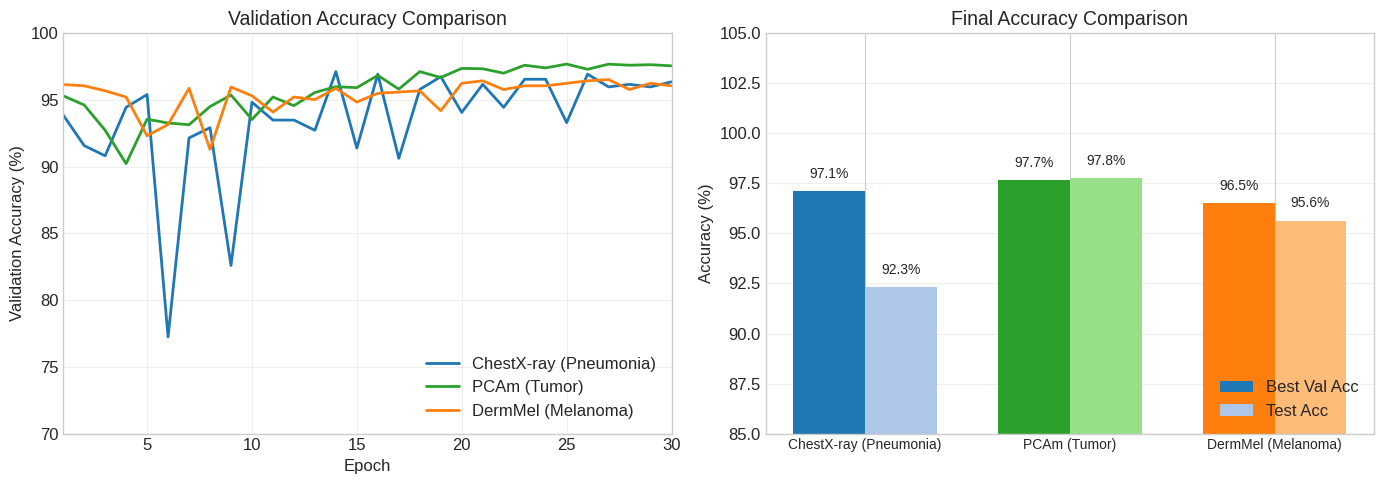


図を保存しました: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/comparison_curves.png


In [14]:
# 全データセットの検証精度を同一グラフで比較
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 検証精度の推移比較
ax1 = axes[0]
for dataset_name, data in training_data.items():
    epochs = data['epochs']
    ax1.plot(epochs, [acc * 100 for acc in data['history']['val_acc']], 
             label=dataset_display_names.get(dataset_name, dataset_name), 
             linewidth=2, color=colors[dataset_name]['train'])

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax1.set_title('Validation Accuracy Comparison', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, 30)
ax1.set_ylim(70, 100)

# 右: 最終精度の棒グラフ比較
ax2 = axes[1]
dataset_names = list(training_data.keys())
display_names = [dataset_display_names.get(name, name) for name in dataset_names]

# ベスト検証精度とテスト精度
best_val_accs = [training_data[name]['config']['best_val_acc'] * 100 for name in dataset_names]
test_accs = [training_data[name]['config']['test_acc'] * 100 for name in dataset_names]

x = np.arange(len(dataset_names))
width = 0.35

bars1 = ax2.bar(x - width/2, best_val_accs, width, label='Best Val Acc', 
                color=[colors[name]['train'] for name in dataset_names])
bars2 = ax2.bar(x + width/2, test_accs, width, label='Test Acc', 
                color=[colors[name]['val'] for name in dataset_names])

# 精度値を棒グラフ上に表示
for bar, acc in zip(bars1, best_val_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)
for bar, acc in zip(bars2, test_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)

ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Final Accuracy Comparison', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(display_names, fontsize=10)
ax2.legend(loc='lower right')
ax2.set_ylim(85, 105)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(BASE_DIR / 'comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n図を保存しました: {BASE_DIR / 'comparison_curves.png'}")

## 7. 最終結果の集計テーブル作成

In [17]:
# 最終結果の集計テーブル
import pandas as pd

summary_data = []
for dataset_name, data in training_data.items():
    config = data['config']
    history = data['history']
    
    row = {
        'データセット': dataset_name,
        'モデル': config.get('model', 'ViT-B/16'),
        'エポック数': config.get('epochs', len(history.get('train_loss', []))),
        'バッチサイズ': config.get('batch_size', 'N/A'),
        '学習率': config.get('lr', 'N/A'),
        '最終訓練損失': f"{history['train_loss'][-1]:.4f}" if history.get('train_loss') else 'N/A',
        '最終検証損失': f"{history['val_loss'][-1]:.4f}" if history.get('val_loss') else 'N/A',
        '最終訓練精度': f"{history['train_acc'][-1]*100:.2f}%" if history.get('train_acc') else 'N/A',
        '最終検証精度': f"{history['val_acc'][-1]*100:.2f}%" if history.get('val_acc') else 'N/A',
        '最良検証精度': f"{config.get('best_val_acc', 0)*100:.2f}%" if config.get('best_val_acc') else 'N/A',
        'テスト精度': f"{config.get('test_acc', 0)*100:.2f}%" if config.get('test_acc') else 'N/A'
    }
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("訓練結果サマリー")
print("=" * 80)
display(df_summary)

# HTML形式で綺麗に表示
from IPython.display import HTML
styled_df = df_summary.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black',
    'padding': '5px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}
])
display(styled_df)

訓練結果サマリー


,データセット,モデル,エポック数,バッチサイズ,学習率,最終訓練損失,最終検証損失,最終訓練精度,最終検証精度,最良検証精度,テスト精度
0,chestxray,vit_b_16,30,32,0.0001,0.2728,0.3297,99.17%,96.37%,97.13%,92.31%
1,pcam,vit_b_16,30,32,0.0001,0.2279,0.2571,98.88%,97.57%,97.69%,97.75%
2,dermmel,vit_b_16,30,32,0.0001,0.2077,0.2811,99.53%,96.07%,96.54%,95.65%


,データセット,モデル,エポック数,バッチサイズ,学習率,最終訓練損失,最終検証損失,最終訓練精度,最終検証精度,最良検証精度,テスト精度
0,chestxray,vit_b_16,30,32,0.000100,0.2728,0.3297,99.17%,96.37%,97.13%,92.31%
1,pcam,vit_b_16,30,32,0.000100,0.2279,0.2571,98.88%,97.57%,97.69%,97.75%
2,dermmel,vit_b_16,30,32,0.000100,0.2077,0.2811,99.53%,96.07%,96.54%,95.65%


## 8. 結果の保存

In [18]:
# グラフを保存
output_dir = BASE_DIR / 'analysis_results'
output_dir.mkdir(parents=True, exist_ok=True)

# 各データセットのグラフを個別に保存
for dataset_name, data in training_data.items():
    history = data['history']
    epochs = range(1, len(history.get('train_loss', [])) + 1)
    
    if history.get('train_loss'):
        # Loss曲線
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training Loss')
        ax.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title(f'{dataset_name} - Loss Curves', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        fig.savefig(str(output_dir / f'{dataset_name}_loss.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        # Accuracy曲線
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(epochs, [acc*100 for acc in history['train_acc']], 'b-', linewidth=2, label='Training Accuracy')
        ax.plot(epochs, [acc*100 for acc in history['val_acc']], 'r-', linewidth=2, label='Validation Accuracy')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        ax.set_title(f'{dataset_name} - Accuracy Curves', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        fig.savefig(str(output_dir / f'{dataset_name}_accuracy.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)

# サマリーテーブルをCSVとして保存
df_summary.to_csv(str(output_dir / 'training_summary.csv'), index=False, encoding='utf-8-sig')

print(f"結果を保存しました: {str(output_dir)}")
print(f"- 各データセットのLoss曲線 (*_loss.png)")
print(f"- 各データセットのAccuracy曲線 (*_accuracy.png)")
print(f"- 訓練結果サマリー (training_summary.csv)")

結果を保存しました: /mnt/data1/gotou/projects/vit/classifiers/checkpoints/analysis_results
- 各データセットのLoss曲線 (*_loss.png)
- 各データセットのAccuracy曲線 (*_accuracy.png)
- 訓練結果サマリー (training_summary.csv)
